In [1]:
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import shap

# np.random.seed(1)

/Users/daanwichmann/PycharmProjects/Explainable AI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data-clf-students/heart.csv')
X = df.drop(['target'],axis=1)
y = df['target']

train, test, labels_train, labels_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=7)

In [3]:
train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
242,38,1,2,138,175,0,1,173,0,0.0,2,4,2
360,48,1,0,122,222,0,0,186,0,0.0,2,0,2
717,56,1,2,130,256,1,0,142,1,0.6,1,1,1
271,44,1,1,120,263,0,1,173,0,0.0,2,0,3
846,35,0,0,138,183,0,1,182,0,1.4,2,0,2


In [4]:
# Fitting a RF classifier
rf = sklearn.ensemble.RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(train, labels_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [5]:
y_pred = rf.predict(test)
print("Accuracy: ", accuracy_score(labels_test, y_pred))

Accuracy:  1.0


In [6]:
# SHAP explanations
explainer = shap.KernelExplainer(rf.predict, shap.kmeans(train, 10))
nb_points_explain = round(0.2*train.shape[0])
shap_values = explainer(train.iloc[0:nb_points_explain, :])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164/164 [00:57<00:00,  2.84it/s]


In [7]:
ref = explainer.expected_value
print("Average predicted output: ",ref)

Average predicted output:  0.5


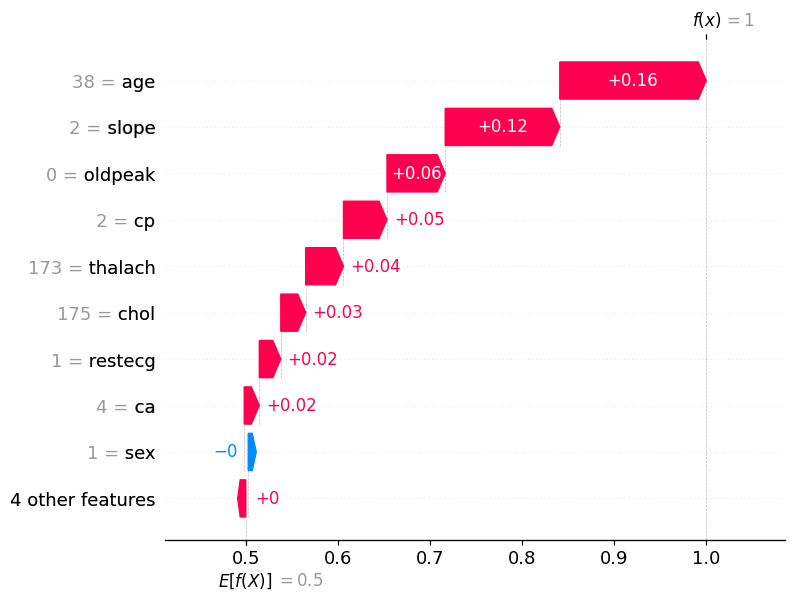

In [8]:
# Waterfall plot for a single explanation
i = 0
shap.plots.waterfall(shap_values[i])

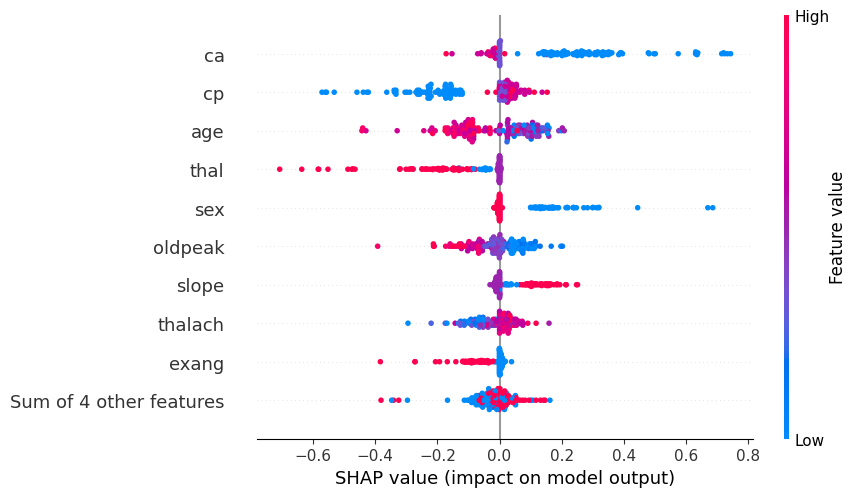

In [9]:
# Beeswarm (aka summary plot)
shap.plots.beeswarm(shap_values)

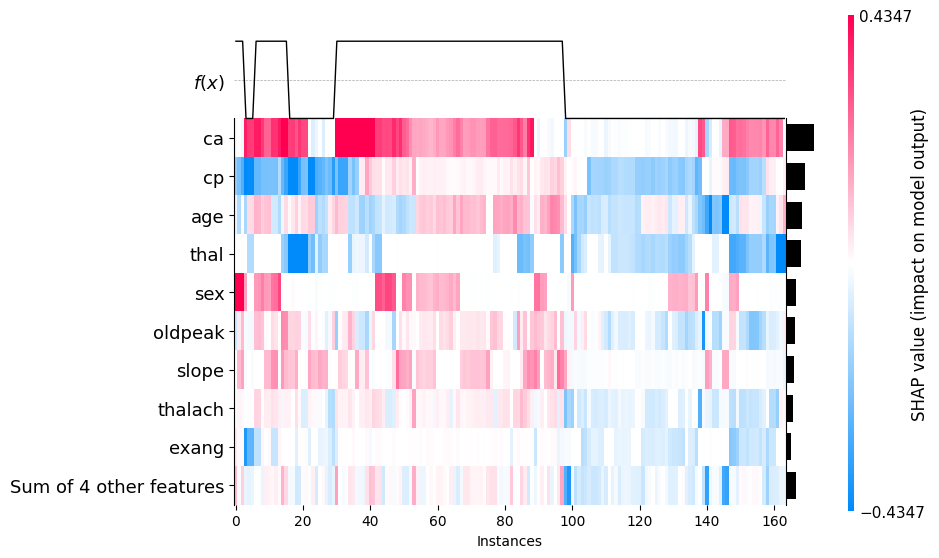

<Axes: xlabel='Instances'>

In [10]:
# Heatmap
shap.plots.heatmap(shap_values)

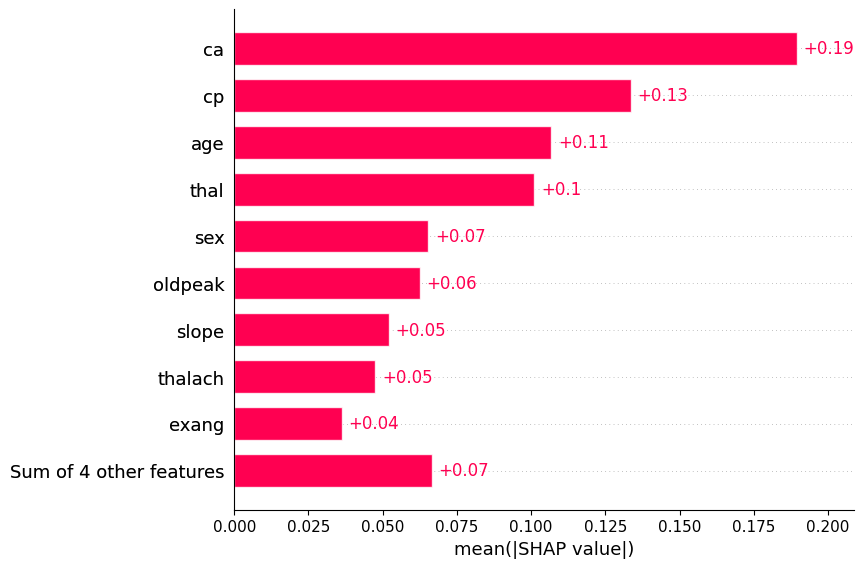

In [11]:
shap.plots.bar(shap_values)

In [12]:
# SHAP explanations
explainer = shap.KernelExplainer(rf.predict, shap.kmeans(train, 10))
nb_points_explain = train.shape[0]
shap_values = explainer(train.iloc[0:nb_points_explain, :])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 820/820 [13:04<00:00,  1.05it/s]


In [13]:
ref = explainer.expected_value
print("Average predicted output: ",ref)

Average predicted output:  0.5


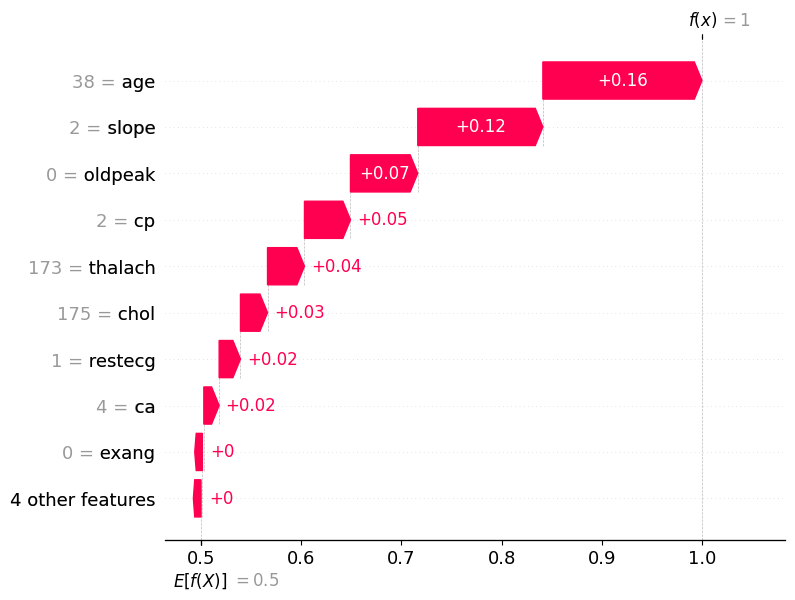

In [14]:
# Waterfall plot for a single explanation
i = 0
shap.plots.waterfall(shap_values[i])

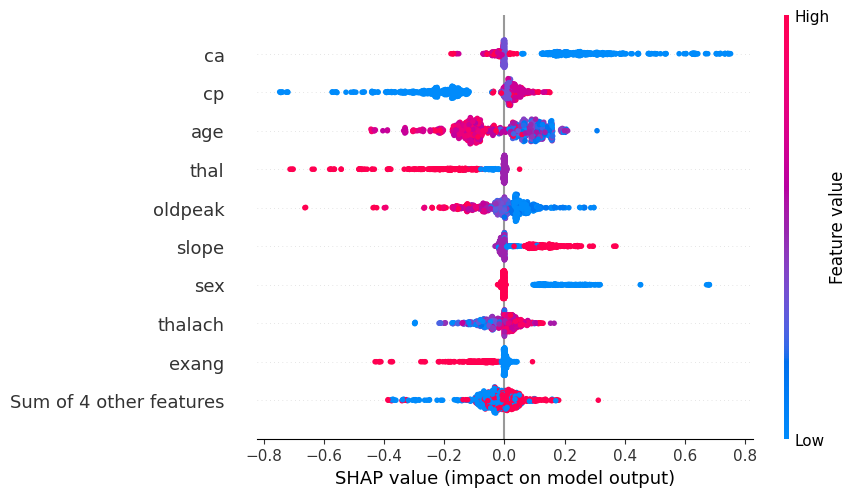

In [15]:
# Beeswarm (aka summary plot)
shap.plots.beeswarm(shap_values)

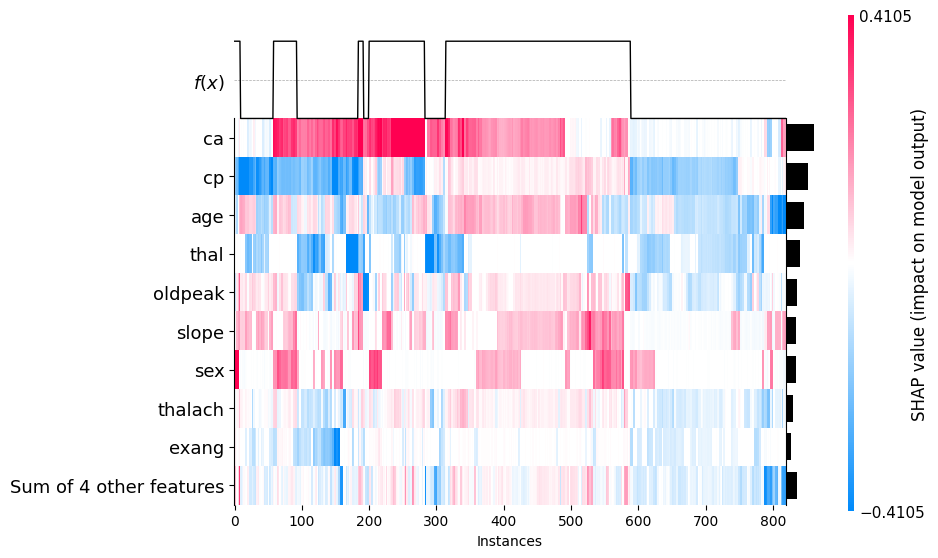

<Axes: xlabel='Instances'>

In [16]:
# Heatmap
shap.plots.heatmap(shap_values)

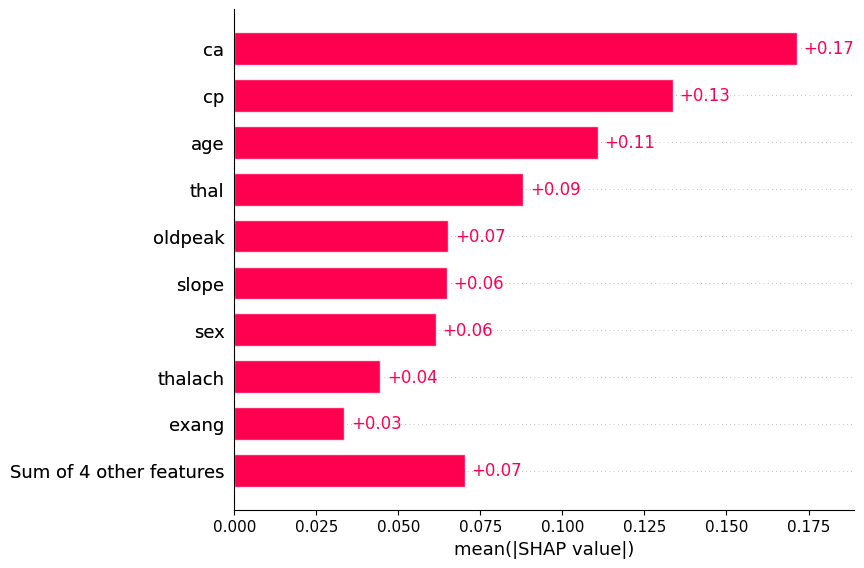

In [17]:
shap.plots.bar(shap_values)

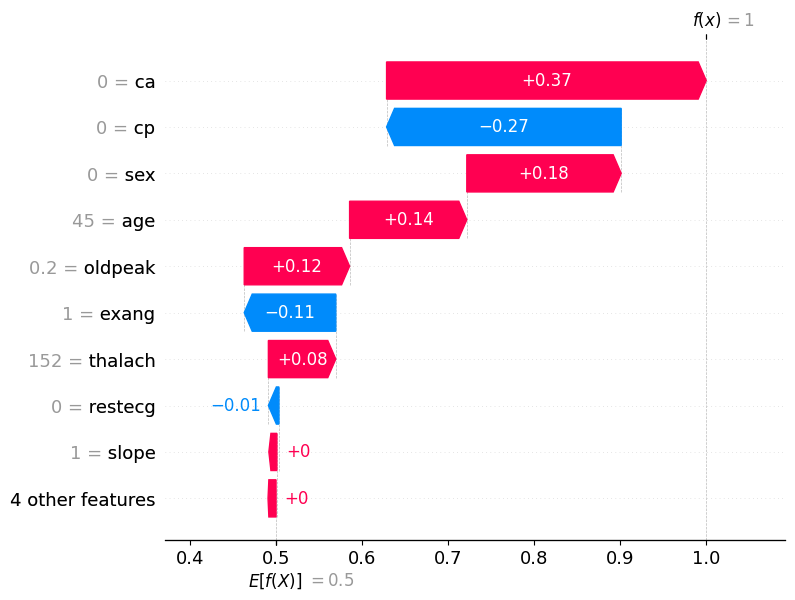

In [19]:
# Waterfall plot for a single explanation
i = 600
shap.plots.waterfall(shap_values[i])

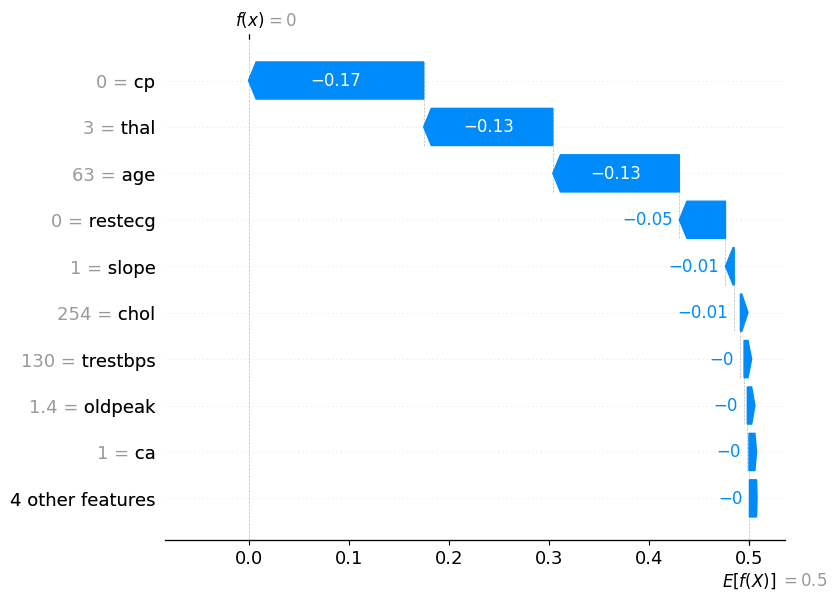

In [20]:
# Waterfall plot for a single explanation
i = 160
shap.plots.waterfall(shap_values[i])

### 